# Разработка A-B-тестирования и анализ результатов

Заказчик — компания, которая разрабатывает развлекательное приложение с функцией «бесконечной» ленты, как, например, в приложениях с короткими видео. В их приложении существует две модели монетизации: первая — ежемесячная платная подписка, которая позволяет пользователям смотреть ленту без рекламы, вторая — демонстрация рекламы для пользователей, которые ещё не оформили подписку.

Команда разработчиков рекомендательных систем создала новый алгоритм рекомендаций, который, по их мнению, будет показывать более интересный контент для каждого пользователя. Нужно рассчитать параметры A/B-теста, который позволит проверить эту гипотезу, и проанализировать его результаты.

## Описание данных

В нашем распоряжении имеются три таблицы:

- `sessions_project_history.csv` — таблица с историческими данными по сессиям пользователей на период с 2025-08-15 по 2025-09-23.

- `sessions_project_test_part.csv` — таблица с данными за первый день проведения A/B-теста, то есть за 2025-10-14.

- `sessions_project_test.csv` — таблица с данными за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02.

У этих таблиц почти совпадает структура и содержание колонок, различаются лишь периоды наблюдения.

Поля таблиц `sessions_project_history.csv`, `sessions_project_test.csv`, `sessions_project_test_part.csv`:

- `user_id` — идентификатор пользователя;

- `session_id` — идентификатор сессии в приложении;

- `session_date` — дата сессии;

- `session_start_ts` — дата и время начала сессии;

- `install_date` — дата установки приложения;

- `session_number` — порядковый номер сессии для конкретного пользователя;

- `registration_flag` — является ли пользователь зарегистрированным;

- `page_counter` — количество просмотренных страниц во время сессии;

- `region` — регион пользователя;

- `device` — тип устройства пользователя;

- `test_group` — тестовая группа (в таблице с историческими данными этого столбца нет).


## Что нужно сделать
Задачи: рассчитать параметры теста, оценить корректность его проведения и проанализировать результаты эксперимента.

### 1. Работа с историческими данными (EDA)

#### 1.1. Загрузка исторических данных
На первом этапе необходимо поработать с историческими данными приложения:

- Импоруем библиотеку pandas.

- Считаем и сохраним в датафрейм `sessions_history` CSV-файл с историческими данными о сессиях пользователей `sessions_project_history.csv`.

- Выведем на экран первые пять строк полученного датафрейма.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from math import ceil
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.proportion import proportions_ztest

In [2]:
sessions_history = pd.read_csv('sessions_project_history.csv')
sessions_history.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


In [3]:
sessions_history.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 435924 entries, 0 to 435923
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   user_id            435924 non-null  object
 1   session_id         435924 non-null  object
 2   session_date       435924 non-null  object
 3   session_start_ts   435924 non-null  object
 4   install_date       435924 non-null  object
 5   session_number     435924 non-null  int64 
 6   registration_flag  435924 non-null  int64 
 7   page_counter       435924 non-null  int64 
 8   region             435924 non-null  object
 9   device             435924 non-null  object
dtypes: int64(3), object(7)
memory usage: 33.3+ MB


In [4]:
sessions_history['session_start_ts'] = pd.to_datetime(sessions_history['session_start_ts'])
sessions_history['session_date'] = pd.to_datetime(sessions_history['session_date'])
sessions_history['install_date'] = pd.to_datetime(sessions_history['install_date'])

#### 1.2. Знакомство с данными
- Для каждого уникального пользователя `user_id` рассчитаем количество уникальных сессий `session_id`.

- Выведем на экран все данные из таблицы `sessions_history` для одного пользователя с наибольшим количеством сессий. Если таких пользователей несколько, выберем любого из них.

- Изучим таблицу для одного пользователя, чтобы лучше понять логику формирования каждого столбца данных.

In [5]:
user_sessions = sessions_history.groupby('user_id')['session_id'].nunique()
user_id_max = user_sessions.idxmax()
user_id_max_sessions = sessions_history[sessions_history['user_id']==user_id_max]
user_id_max_sessions

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android
325557,10E0DEFC1ABDBBE0,031BD7A67048105B,2025-08-19,2025-08-19 13:23:55,2025-08-14,6,0,2,CIS,Android
345336,10E0DEFC1ABDBBE0,FF4315CF4AD4B100,2025-08-20,2025-08-20 19:31:54,2025-08-14,7,0,2,CIS,Android
377532,10E0DEFC1ABDBBE0,4045FEA0747203B4,2025-08-22,2025-08-22 17:54:13,2025-08-14,8,0,2,CIS,Android
403538,10E0DEFC1ABDBBE0,344B086C421C7F37,2025-08-24,2025-08-24 14:46:13,2025-08-14,9,0,2,CIS,Android
414743,10E0DEFC1ABDBBE0,054F20BA371E4C9D,2025-08-25,2025-08-25 18:36:41,2025-08-14,10,0,3,CIS,Android


#### 1.3. Анализ числа регистраций
Одна из важнейших метрик продукта — число зарегистрированных пользователей. Используя исторические данные, визуализируем, как менялось число регистраций в приложении за время его существования. Пользователь считается зарегистрированным только в день совершения регистрации. Таким образом, необходимо проанализировать количество зарегистрированных активных пользователей за каждый день без накопления (аналог DAU, но для регистраций пользователей).

- Агрегируем исторические данные и рассчитаем число уникальных пользователей и число зарегистрированных пользователей для каждого дня наблюдения. Для простоты считаем, что у пользователя в течение дня бывает одна сессия максимум и статус регистрации в течение одного дня не может измениться.

- Построим линейные графики общего числа пользователей и общего числа зарегистрированных пользователей по дням, отобразим их на одном графике.

- Построим отдельный линейный график доли зарегистрированных пользователей от всех пользователей по дням.

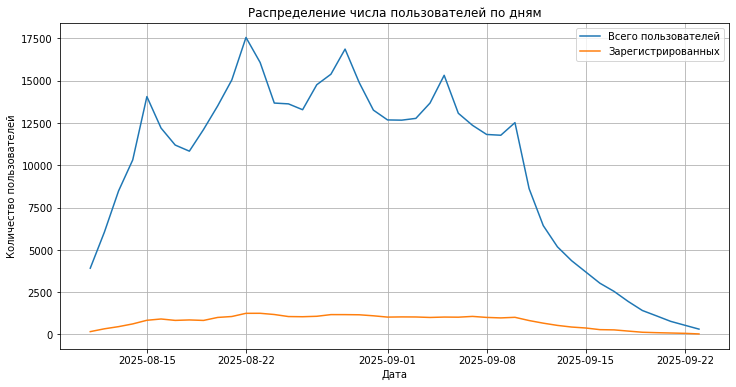

In [6]:
users_total = sessions_history.groupby('session_date')['user_id'].nunique().sort_index()
users_register = sessions_history[sessions_history['registration_flag']==1].groupby('session_date')['user_id'].nunique().sort_index()
plt.figure(figsize=(12, 6))
plt.plot(users_total.index, users_total.values, label='Всего пользователей')
plt.plot(users_register.index, users_register.values, label='Зарегистрированных')
plt.title('Распределение числа пользователей по дням')
plt.xlabel('Дата')
plt.ylabel('Количество пользователей')
plt.legend()
plt.grid()
plt.show()

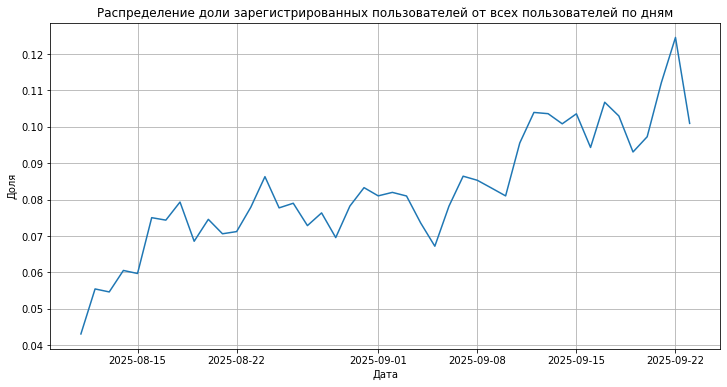

In [7]:
users_parts = users_register / users_total
plt.figure(figsize=(12, 6))
plt.plot(users_parts.index, users_parts.values)
plt.title('Распределение доли зарегистрированных пользователей от всех пользователей по дням')
plt.xlabel('Дата')
plt.ylabel('Доля')
plt.grid()
plt.show()

#### 1.4. Анализ числа просмотренных страниц
Другая важная метрика продукта — число просмотренных страниц в приложении. Чем больше страниц просмотрено, тем сильнее пользователь увлечён контентом, а значит, выше шансы, что он зарегистрируется и оплатит подписку.

Проанализируем число просмотренных страниц во время первых сессий пользователей. Найдём количество первых сессий для каждого значения количества просмотренных страниц.

Построим столбчатую диаграмму, где по оси X будет число просмотренных страниц, по оси Y — количество сессий.

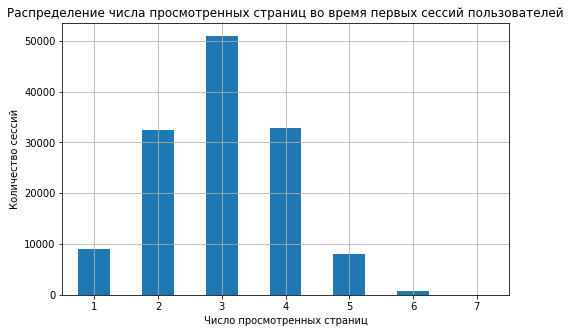

In [8]:
first_sessions = sessions_history[sessions_history['session_number']==1]
session_count = first_sessions.groupby('page_counter')['session_id'].count()
session_count.plot(kind='bar',
               title=f'Распределение числа просмотренных страниц во время первых сессий пользователей',
               xlabel='Число просмотренных страниц',                   
               ylabel='Количество сессий',
               rot=0,
               figsize=(8, 5))
plt.grid()
plt.show()

#### 1.5. Доля пользователей, просмотревших более четырёх страниц
Продуктовая команда продукта считает, что сессии, в рамках которых пользователь просмотрел 4 и более страниц, говорят об удовлетворённости контентом и алгоритмами рекомендаций. Этот показатель является важной прокси-метрикой для продукта.

- В датафрейме `sessions_history` создадим дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если было просмотрено меньше.

- Построим график со средним значением доли успешных сессий от всех первых сессий пользователей. Данные визуализируем по дням за весь период наблюдения.

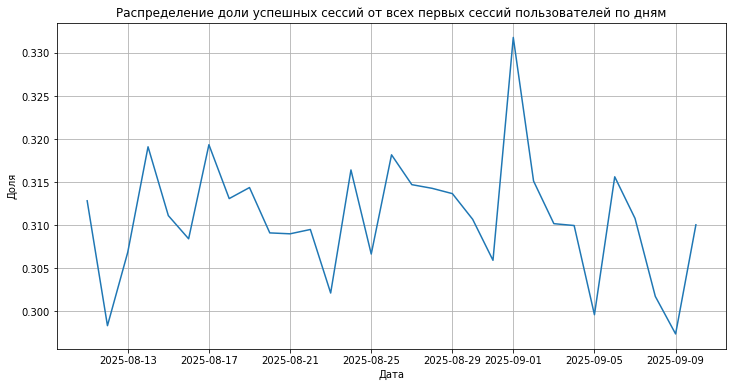

In [9]:
sessions_history['good_session'] = 0
sessions_history.loc[sessions_history['page_counter'] >= 4, 'good_session'] = 1
first_sessions = sessions_history[sessions_history['session_number']==1]
total_session_count = first_sessions.groupby('session_date')['session_id'].count()
good_session_count = first_sessions[first_sessions['good_session']==1].groupby('session_date')['session_id'].count()
good_part = good_session_count / total_session_count
plt.figure(figsize=(12, 6))
plt.plot(good_part.index, good_part.values)
plt.title('Распределение доли успешных сессий от всех первых сессий пользователей по дням')
plt.xlabel('Дата')
plt.ylabel('Доля')
plt.grid()
plt.show()

### 2. Подготовка к тесту
При планировании теста необходимо проделать несколько важных шагов:

- Определиться с целевой метрикой.

- Рассчитать необходимый размер выборки.

- Исходя из текущих значений трафика рассчитать необходимую длительность проведения теста.

#### 2.1. Расчёт размера выборки
Рассчитаем необходимое для эксперимента количество пользователей, используя следующие параметры:

- Уровень значимости — 0.05.

- Вероятность ошибки второго рода — 0.2.

- Минимальный детектируемый эффект, или MDE, — 3%.

In [10]:
# Зададим параметры:
alpha = 0.05  # Уровень значимости
beta = 0.2  # Ошибка второго рода
power = 1 - beta  # Мощность теста
p = 0.3 # Базовый уровень доли
mde = 0.3 * 0.03  # Минимальный детектируемый эффект
effect_size = proportion_effectsize(p, p + mde)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Расчёт размера выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1 # Равномерное распределение выборок
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 41040


#### 2.2. Расчёт длительности A/B-теста

Используем данные о количестве пользователей в каждой выборке и среднем количестве пользователей приложения. Рассчитаем длительность теста, разделив одно на другое.

- Рассчитаем среднее количество уникальных пользователей приложения в день.

- Определим длительность теста, исходя из рассчитанного значения размера выборок и среднего дневного трафика приложения. Количество дней округлим в большую сторону.

In [11]:
# Среднее количество пользователей приложения в день по историческим данным
daily_users = sessions_history.groupby('session_date')['user_id'].nunique()
avg_daily_users = int(daily_users.mean())

# Рассчитываем длительность теста в днях как отношение размера выборки к среднему числу пользователей
test_duration = ceil(sample_size*2/avg_daily_users)

print(f"Рассчитанная длительность A/B-теста при текущем уровене трафика в {avg_daily_users} пользователей в день составит {test_duration} дней")

Рассчитанная длительность A/B-теста при текущем уровене трафика в 9907 пользователей в день составит 9 дней


### 3. Мониторинг А/В-теста

#### 3.1. Проверка распределения пользователей

A/B-тест успешно запущен, и уже доступны данные за первые три дня. На этом этапе нужно убедиться, что всё идёт хорошо: пользователи разделены правильным образом, а интересующие нас метрики корректно считаются.

- Считаем и сохраним в датафрейм `sessions_test_part` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test_part.csv`.

- Рассчитаем количество уникальных пользователей в каждой из экспериментальных групп для одного дня наблюдения.

- Рассчитаем и выведем на экран процентную разницу в количестве пользователей в группах A и B. Построим визуализацию, на которой будет видно возможное различие двух групп.

Для расчёта процентной разницы воспользуемся формулой:
$$P = 100 \cdot  \frac{|A − B|}{A}$$

Количество уникальных пользователей группы A = 1477, группы B = 1466
Процентная разница в количестве пользователей в группах A и B = 0.74%


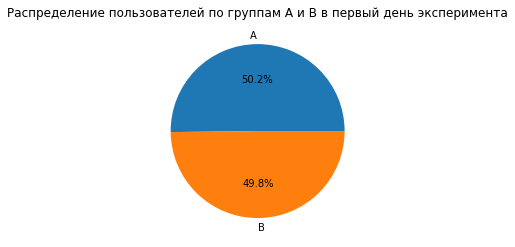

In [12]:
sessions_test_part = pd.read_csv('sessions_project_test_part.csv')
df_exp = sessions_test_part.drop_duplicates('user_id')
df_group = df_exp.groupby('test_group')['user_id'].nunique()
count_a = df_group['A']
count_b = df_group['B']
print(f'Количество уникальных пользователей группы A = {count_a}, группы B = {count_b}')
p = round(100 * abs(count_a - count_b) / count_a, 2)
print(f'Процентная разница в количестве пользователей в группах A и B = {p}%')

plt.figure(figsize=(4, 4))
df_group.plot(kind='pie', autopct='%1.1f%%', legend=False, title='Распределение пользователей по группам A и B в первый день эксперимента')
plt.ylabel('')
plt.title('Распределение пользователей по группам A и B в первый день эксперимента')
plt.show()

#### 3.2. Проверка пересечений пользователей
Помимо проверки равенства количества пользователей в группах, полезно убедиться в том, что группы независимы. Для этого нужно убедиться, что никто из пользователей случайно не попал в обе группы одновременно.

- Рассчитаем количество пользователей, которые встречаются одновременно в группах A и B, или убедимся, что таких нет.

In [13]:
group_a = df_exp[df_exp['test_group']=='A']['user_id']
group_b = df_exp[df_exp['test_group']=='B']['user_id']
intersection = list(set(group_a) & set(group_b))
print(f'Количество пользователей, которые встречаются одновременно в группах A и B: {len(intersection)}')

Количество пользователей, которые встречаются одновременно в группах A и B: 0


#### 3.3. Равномерность разделения пользователей по устройствам
Полезно также убедиться в том, что пользователи равномерно распределены по всем доступным категориальным переменным — типам устройств и регионам.

Построим две диаграммы:

- доля каждого типа устройства для пользователей из группы A,

- доля каждого типа устройства для пользователей из группы B.

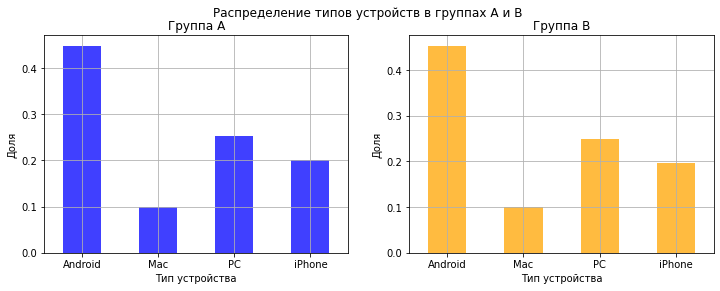

In [19]:
device_a = df_exp[df_exp['test_group']=='A'].groupby('device')['user_id'].nunique().sort_index() / df_exp[df_exp['test_group']=='A']['user_id'].nunique()
device_b = df_exp[df_exp['test_group']=='B'].groupby('device')['user_id'].nunique().sort_index() / df_exp[df_exp['test_group']=='B']['user_id'].nunique()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

device_a.plot(kind='bar', rot=0, alpha=0.75, color='blue', ax=axes[0])
axes[0].set_xlabel('Тип устройства')
axes[0].set_ylabel('Доля')
axes[0].set_title('Группа A')
axes[0].grid()

device_b.plot(kind='bar', rot=0, alpha=0.75, color='orange', ax=axes[1])
axes[1].set_xlabel('Тип устройства')
axes[1].set_ylabel('Доля')
axes[1].set_title('Группа B')
axes[1].grid()

fig.suptitle('Распределение типов устройств в группах A и B')
plt.show()

#### 3.4. Равномерность распределения пользователей по регионам
Теперь убедимся, что пользователи равномерно распределены по регионам.

Построим две диаграммы:

- доля каждого региона для пользователей из группы A,

- доля каждого региона для пользователей из группы B.

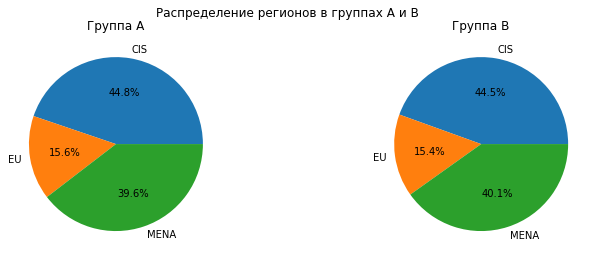

In [20]:
region_a = df_exp[df_exp['test_group']=='A'].groupby('region')['user_id'].nunique().sort_index() / df_exp[df_exp['test_group']=='A']['user_id'].nunique()
region_b = df_exp[df_exp['test_group']=='B'].groupby('region')['user_id'].nunique().sort_index() / df_exp[df_exp['test_group']=='B']['user_id'].nunique()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

region_a.plot(kind='pie', ax=axes[0], autopct='%1.1f%%')
axes[0].set_ylabel('')
axes[0].set_title('Группа A')

region_b.plot(kind='pie', ax=axes[1], autopct='%1.1f%%')
axes[1].set_ylabel('')
axes[1].set_title('Группа B')

fig.suptitle('Распределение регионов в группах A и B')
plt.show()

#### 3.5. Вывод после проверки A/B-теста

- Процентное соотношение пользователей в группах A и B в первый день A/B-теста составляет 50.2% к 49.8%. Расхождение количества пользователей между группами минимальное, им можно пренебречь.
- Выборки являются независимыми: пользователи, попавшие в обе группы, отсутствуют.
- Распределение количества уникальных пользователей по категориальным переменным (типам устройств и регионам) в тестовой и контрольной группах практически совпадает.

Таким образом, пользователи распределены между группами равномерно, аудитория в них сопоставима. Следовательно, A/B-тест проходит корректно.

---

### 4. Проверка результатов A/B-теста

A/B-тест завершён, и у нас есть результаты за все дни проведения эксперимента. Необходимо убедиться в корректности теста и верно интерпретировать результаты.

#### 4.1. Получение результатов теста и подсчёт основной метрики

- Считаем и сохраним в датафрейм `sessions_test` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test.csv`.

- В датафрейме `sessions_test` создадим дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если просмотрено меньше.

In [16]:
sessions_test = pd.read_csv('sessions_project_test.csv')
sessions_test['good_session'] = 0
sessions_test.loc[sessions_test['page_counter'] >= 4, 'good_session'] = 1

#### 4.2 Формулировка нулевой и альтернативной гипотез. Определение целевой, прокси- и барьерных метрик


Перед тем как проводить А/B-тест, необходимо сформулировать нулевую и альтернативную гипотезы. Изначальное условие: команда разработчиков рекомендательных систем создала новый алгоритм, который, по их мнению, будет показывать более интересный контент для каждого пользователя.

Целевая метрика - доля успешных первых сессий. Обозначим {$p_a$, $p_b$} как доли успешных первых сессий для старой и новой версий алгоритма. Сформулируем гипотезы для А/B-теста:
- Нулевая гипотеза $H_0$: доля успешных первых сессий не различается для старого и нового алгоритма - $p_a$ = $p_b$.
- Альтернативная гипотеза $H_1$: доля успешных первых сессий выше для нового алгоритма - $p_a$ < $p_b$.

В качестве прокси-метрики можно выбрать среднее количество просмотренных страниц во время первой сессии.  
В качестве барьерной метрики можно выбрать стабильность приложения.

---

#### 4.3. Сравнение доли успешных сессий

Перейдем к анализу ключевой метрики — доле успешных первых сессий.

Используем созданный на первом шаге задания столбец `good_session` и рассчитаем долю успешных первых сессий для выборок A и B, а также разницу в этом показателе.

In [17]:
# выберем первые сессии
df_exp = sessions_test[sessions_test['session_number']==1]
# размер выборок A и B
n_a = df_exp[df_exp['test_group']=='A'].shape[0]
n_b = df_exp[df_exp['test_group']=='B'].shape[0]
print(f'Размер выборок n_a = {n_a}, n_b = {n_b}')
# количество успехов в выборках A и B
m_a = df_exp[(df_exp['test_group']=='A')&(df_exp['good_session']==1)].shape[0]
m_b = df_exp[(df_exp['test_group']=='B')&(df_exp['good_session']==1)].shape[0]
print(f'Количество успехов в выборках m_a = {m_a}, m_b = {m_b}')
# доля успешных первых сессий для выборок A и B
p_a = m_a / n_a
p_b = m_b / n_b
print(f'Доля успешных первых сессий для выборок p_a = {round(p_a, 4)}, p_b = {round(p_b, 4)}')
print(f'Разница в доле успешных первых сессий в выборках составляет {round((p_b - p_a)*100, 2)}%')
if (p_a*n_a > 10)and((1-p_a)*n_a > 10)and(p_b*n_b > 10)and((1-p_b)*n_b > 10):
    print('Предпосылка о достаточном количестве данных выполняется')
else:
    print('Предпосылка о достаточном количестве данных НЕ выполняется')

Размер выборок n_a = 15162, n_b = 15416
Количество успехов в выборках m_a = 4787, m_b = 4851
Доля успешных первых сессий для выборок p_a = 0.3157, p_b = 0.3147
Разница в доле успешных первых сессий в выборках составляет -0.11%
Предпосылка о достаточном количестве данных выполняется


#### 4.4. Насколько статистически значимо изменение ключевой метрики

- Используя статистический тест, рассчитаем, является ли изменение в метрике доли успешных сессий статистически значимым.

In [18]:
# Проводим Z-тест пропорций
   
alpha = 0.05

stat_ztest, p_value_ztest = proportions_ztest(
    [m_a, m_b],
    [n_a, n_b],
    alternative='smaller' # так как H_1: p_a < p_b
)

if p_value_ztest > alpha:
    print(f'pvalue={p_value_ztest} > {alpha}')
    print('Нулевая гипотеза находит подтверждение.')
else:
    print(f'pvalue={p_value_ztest} < {alpha}')
    print('Нулевая гипотеза не находит подтверждения.')

pvalue=0.5783523649187868 > 0.05
Нулевая гипотеза находит подтверждение.


#### 4.5. Вывод по результатам A/B-эксперимента

- Целевой метрикой эксперимента являлась доля успешных первых сессий. Количество пользователей в контрольной группе составило 15162, в тестовой - 15416. Период сбора данных: 19 дней. 
- Внедрение нового алгоритма рекомендаций не привело к росту ключевой метрики в тестовой группе, наоборот, в результате эксперимента она снизилась на 0.11 процентных пункта (p_A = 0.3157, p_B = 0.3147).  
- При оценке статистической значимости данного эффекта значение p-value = 0.58 получилось выше заданного уровня значимости 0.05, поэтому нулевая гипотеза о равенстве доли успешных первых сессий в тестовой и контрольной группе не может быть отвергнута. Это означает, что у нас нет достаточных оснований утверждать, что новый алгоритм влияет на долю успешных первых сессий.
- На основе анализа метрики "доля успешных первых сессий" внедрение нового алгоритма рекомендаций в приложение нецелесообразно.